# 🔥 Algerian Forest Fires — ML Classification Project by Alok

**Dataset:** Algerian Forest Fires Dataset  
**Goal:** Predict whether a fire occurred or not based on weather and fire index features  
**Algorithms used:** Logistic Regression, Decision Tree, Random Forest, KNN

## Step 1 — Import Libraries

First let's import everything we'll need for this project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2 — Load the Dataset

In [2]:
df = pd.read_csv('Algerian_forest_fires.csv')
print("Shape of dataset:", df.shape)
df.head(10)

Shape of dataset: (243, 15)


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
5,6,6,2012,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0
6,7,6,2012,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0
7,8,6,2012,30,73,15,0.0,86.6,12.1,38.3,5.6,13.5,7.1,fire,0
8,9,6,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire,0
9,10,6,2012,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0.9,not fire,0


## Step 3 — Data Exploration

Let's understand what we're working with.

In [3]:
print("Column names:")
print(df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

Column names:
['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region']

Data types:
day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
Region           int64
dtype: object


In [4]:
print("Basic statistics:")
df.describe()

Basic statistics:


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64


## Step 4 — Data Cleaning

The dataset has some whitespace issues in column names and the target column. Let's fix that.

In [6]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Strip whitespace from all string columns
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Check unique values in the target column
print("Unique values in 'Classes':", df['Classes'].unique())

Unique values in 'Classes': ['not fire' 'fire']


In [7]:
# Drop rows where Classes is NaN or not fire/fire
df = df[df['Classes'].isin(['fire', 'not fire'])]
print("Cleaned dataset shape:", df.shape)
print("Class distribution:")
print(df['Classes'].value_counts())

Cleaned dataset shape: (243, 15)
Class distribution:
Classes
fire        137
not fire    106
Name: count, dtype: int64


In [8]:
# Convert all feature columns to numeric (some may have been read as strings)
feature_cols = ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN after conversion
df.dropna(inplace=True)
print("Final dataset shape:", df.shape)

Final dataset shape: (243, 15)


## Step 5 — Data Visualisation

Let's explore the data visually before building models.

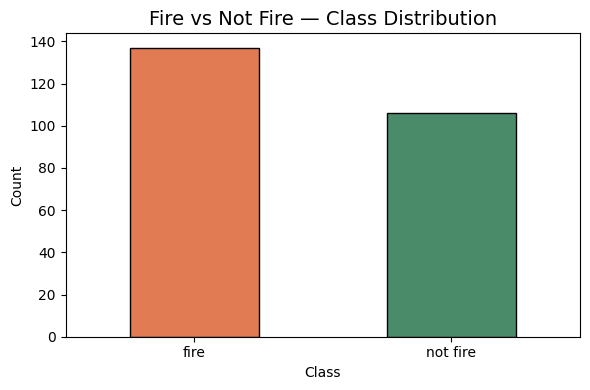

In [9]:
# Class distribution bar chart
plt.figure(figsize=(6, 4))
df['Classes'].value_counts().plot(kind='bar', color=['#E07B54', '#4A8C6A'], edgecolor='black')
plt.title('Fire vs Not Fire — Class Distribution', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

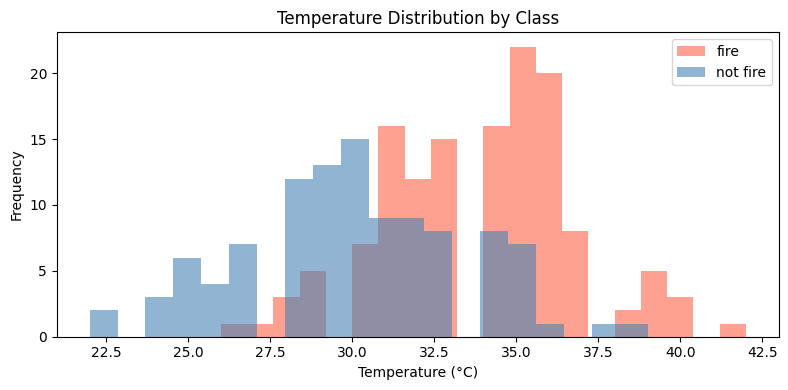

In [10]:
# Distribution of Temperature by class
plt.figure(figsize=(8, 4))
for label, color in zip(['fire', 'not fire'], ['tomato', 'steelblue']):
    subset = df[df['Classes'] == label]['Temperature']
    plt.hist(subset, bins=20, alpha=0.6, label=label, color=color)
plt.title('Temperature Distribution by Class')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

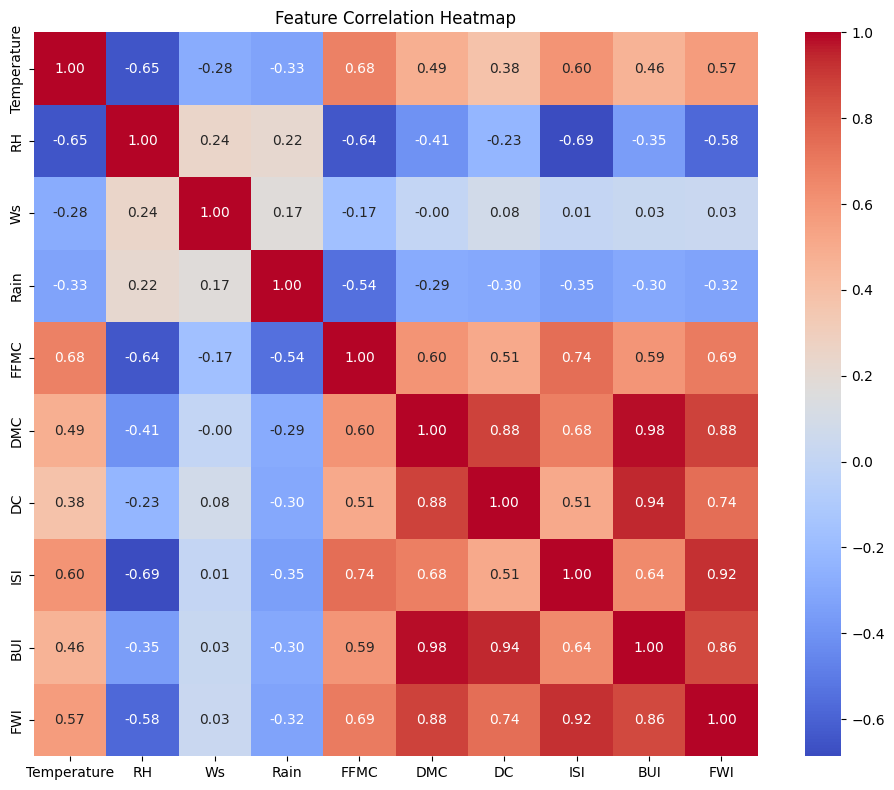

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

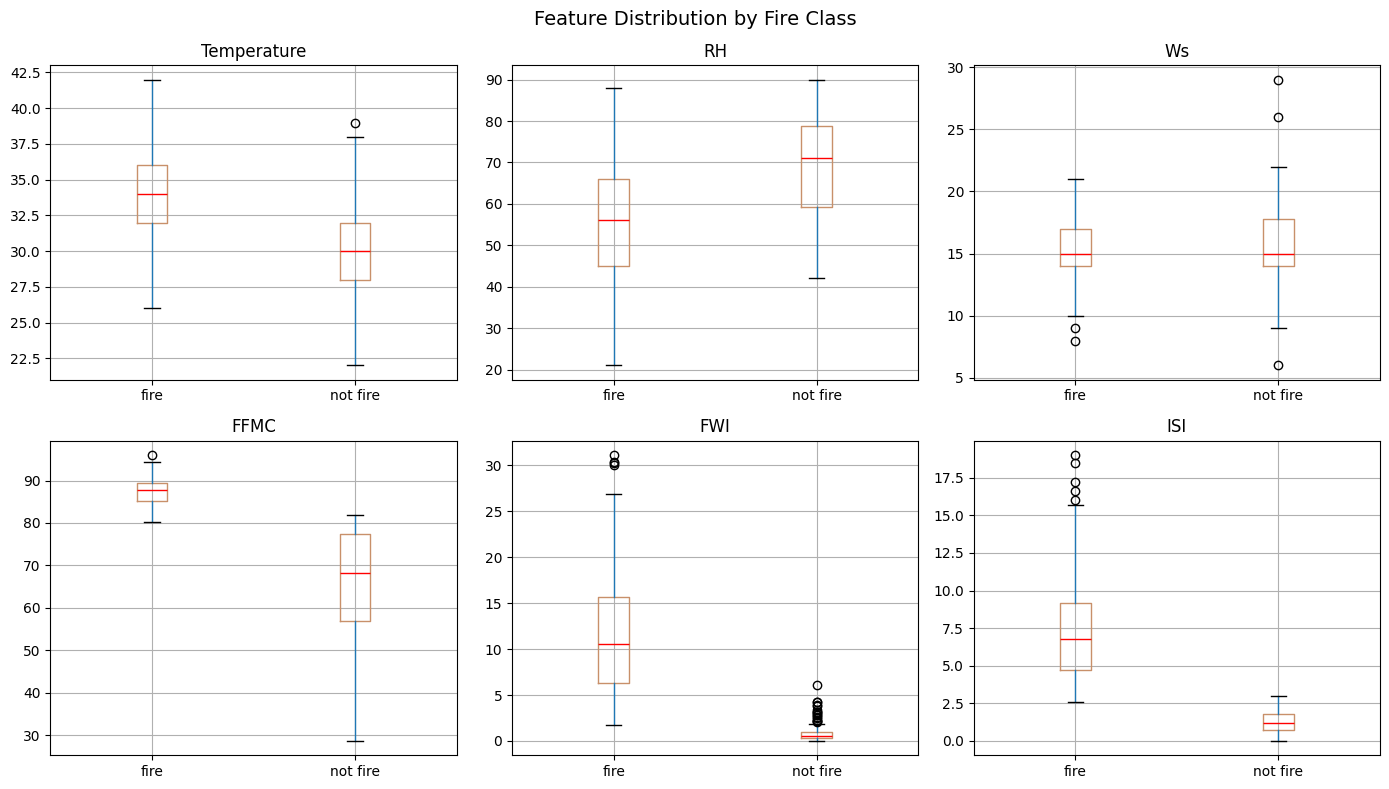

In [12]:
# Boxplots for key features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features_to_plot = ['Temperature', 'RH', 'Ws', 'FFMC', 'FWI', 'ISI']

for ax, feature in zip(axes.flatten(), features_to_plot):
    df.boxplot(column=feature, by='Classes', ax=ax, 
               boxprops=dict(color='#C8906A'),
               medianprops=dict(color='red'))
    ax.set_title(feature)
    ax.set_xlabel('')

plt.suptitle('Feature Distribution by Fire Class', fontsize=14)
plt.tight_layout()
plt.show()

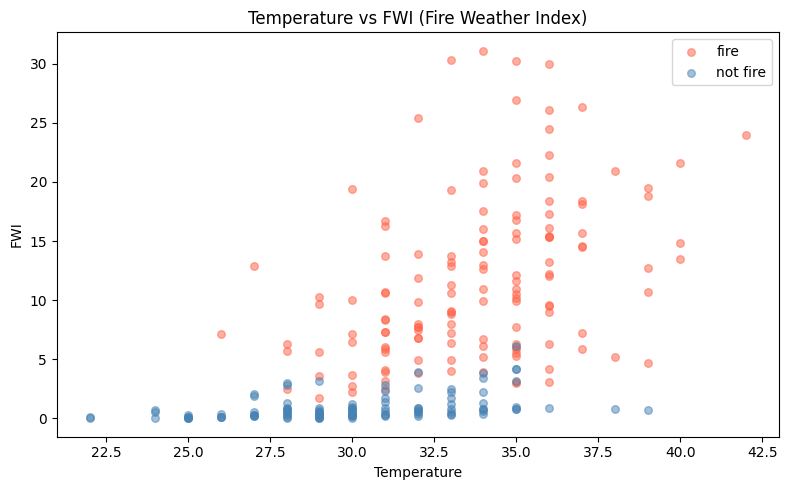

In [13]:
# Scatter plot — Temperature vs FWI
plt.figure(figsize=(8, 5))
for label, color in zip(['fire', 'not fire'], ['tomato', 'steelblue']):
    subset = df[df['Classes'] == label]
    plt.scatter(subset['Temperature'], subset['FWI'], 
                alpha=0.5, label=label, color=color, s=30)
plt.title('Temperature vs FWI (Fire Weather Index)')
plt.xlabel('Temperature')
plt.ylabel('FWI')
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 — Prepare Data for ML

Encode the target, select features, split into train/test.

In [14]:
# Encode target: fire = 1, not fire = 0
le = LabelEncoder()
df['Classes_encoded'] = le.fit_transform(df['Classes'])
print("Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[feature_cols]
y = df['Classes_encoded']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Encoding: {'fire': np.int64(0), 'not fire': np.int64(1)}
Feature shape: (243, 10)
Target shape: (243,)


In [15]:
# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 194
Testing samples:  49


In [16]:
# Feature scaling — important for Logistic Regression and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling done!")

Scaling done!


## Step 7 — Train ML Models

We'll try 4 different algorithms and compare them.

### Model 1 — Logistic Regression

In [17]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred_lr, target_names=['not fire', 'fire']))

Logistic Regression Accuracy: 95.92 %

              precision    recall  f1-score   support

    not fire       0.96      0.96      0.96        28
        fire       0.95      0.95      0.95        21

    accuracy                           0.96        49
   macro avg       0.96      0.96      0.96        49
weighted avg       0.96      0.96      0.96        49



### Model 2 — Decision Tree

In [18]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred_dt, target_names=['not fire', 'fire']))

Decision Tree Accuracy: 97.96 %

              precision    recall  f1-score   support

    not fire       0.97      1.00      0.98        28
        fire       1.00      0.95      0.98        21

    accuracy                           0.98        49
   macro avg       0.98      0.98      0.98        49
weighted avg       0.98      0.98      0.98        49



### Model 3 — Random Forest

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred_rf, target_names=['not fire', 'fire']))

Random Forest Accuracy: 95.92 %

              precision    recall  f1-score   support

    not fire       0.96      0.96      0.96        28
        fire       0.95      0.95      0.95        21

    accuracy                           0.96        49
   macro avg       0.96      0.96      0.96        49
weighted avg       0.96      0.96      0.96        49



### Model 4 — K-Nearest Neighbors (KNN)

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", round(accuracy_score(y_test, y_pred_knn) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred_knn, target_names=['not fire', 'fire']))

KNN Accuracy: 93.88 %

              precision    recall  f1-score   support

    not fire       0.93      0.96      0.95        28
        fire       0.95      0.90      0.93        21

    accuracy                           0.94        49
   macro avg       0.94      0.93      0.94        49
weighted avg       0.94      0.94      0.94        49



## Step 8 — Compare Model Accuracies

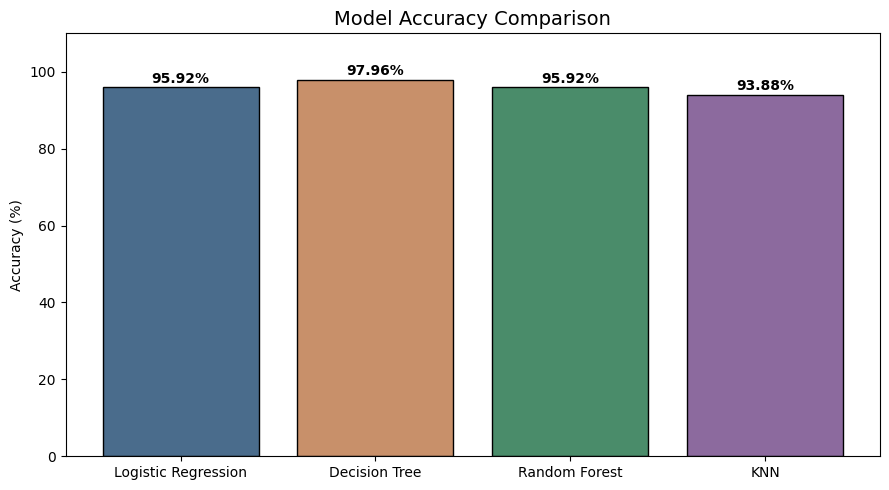

Best model: Decision Tree with 97.96% accuracy


In [21]:
models      = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
accuracies  = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_knn),
]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, [a * 100 for a in accuracies],
               color=['#4A6C8C', '#C8906A', '#4A8C6A', '#8C6A9E'], edgecolor='black')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

best_idx = accuracies.index(max(accuracies))
print(f"Best model: {models[best_idx]} with {accuracies[best_idx]*100:.2f}% accuracy")

## Step 9 — Confusion Matrices

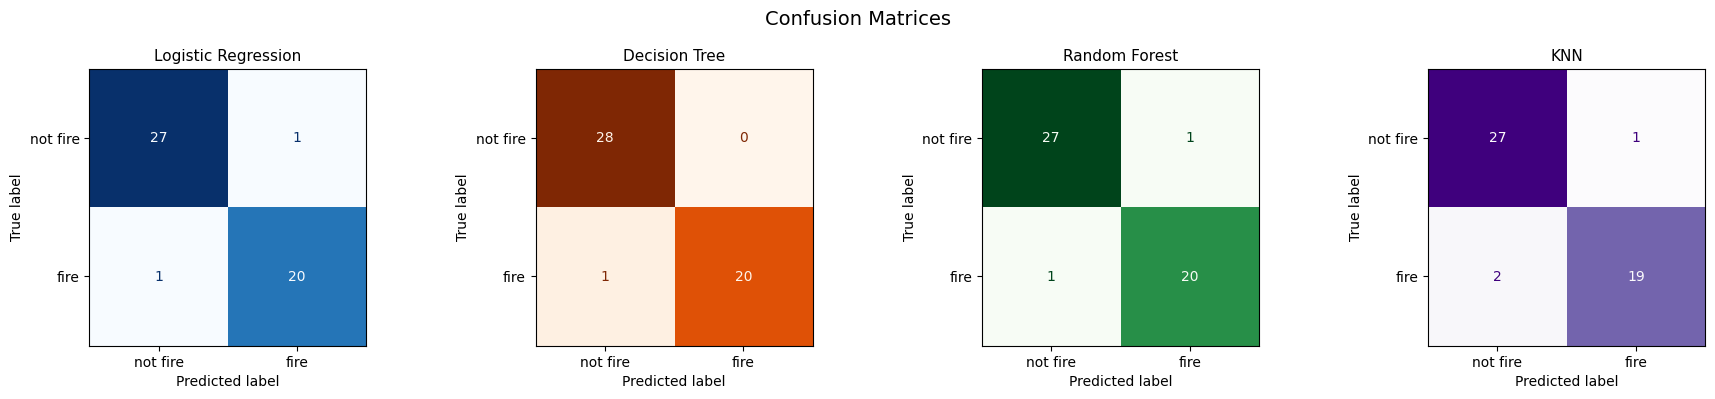

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

preds  = [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_knn]
names  = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
colors = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, pred, name, cmap in zip(axes, preds, names, colors):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['not fire', 'fire'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

## Step 10 — Feature Importance (Random Forest)

Let's see which features matter the most.

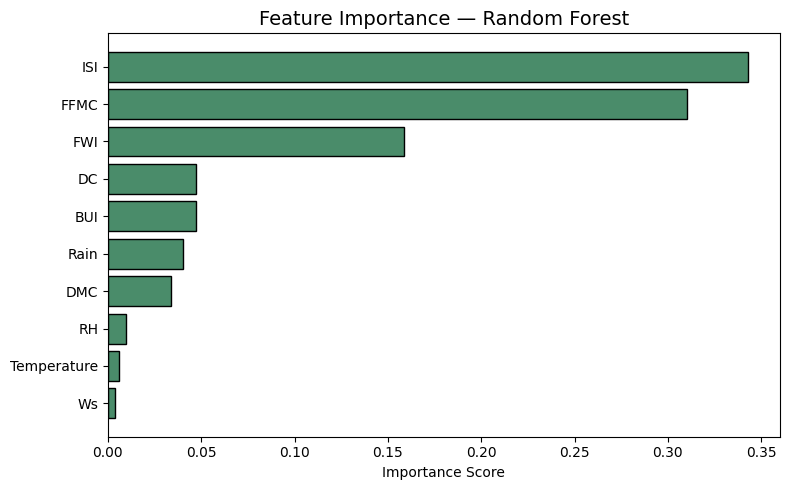

In [23]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='#4A8C6A', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Summary

| Model | Notes |
|---|---|
| Logistic Regression | Simple baseline, works well on scaled data |
| Decision Tree | Interpretable but can overfit |
| Random Forest | Usually best accuracy, handles non-linearity well |
| KNN | Simple but sensitive to scaling and k value |

**Key takeaway:** Random Forest generally performs best on this dataset because it handles the non-linear relationships between weather features and fire occurrence.